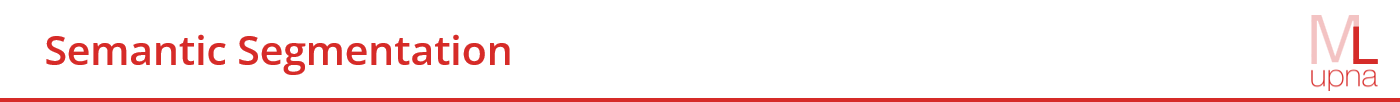

In this exercise, you will learn the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a core task in computer vision where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike classification, which predicts a single label for an entire image, or detection, which localizes objects with bounding boxes, semantic segmentation provides a much more detailed and structured understanding of visual content.

We will use the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, which contains images of people annotated with pixel-level labels for different clothing categories. To simplify the problem and illustrate the task of segmentation, we will reduce the dataset into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

![CCP Dataset](https://raw.githubusercontent.com/bearpaw/clothing-co-parsing/master/example.jpg)

Throughout the notebook, you will explore different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

By the end of this practice, you will understand both the limitations of early approaches and the advantages of modern architectures in semantic segmentation.

## <span style="color:#D52B29">Sliding Window</span>

One of the earliest strategies for <span style="color:#D52B29">semantic segmentation</span> is the <span style="color:#D52B29">sliding window approach</span>. In this method, a fixed-size window is moved across the image, and a classifier predicts the <span style="color:#D52B29">label of the central pixel</span> based on the content inside the window.

While simple to implement, this approach, as we will see in this section, has several drawbacks:

- It is <span style="color:#D52B29">computationally expensive</span> since the network runs on many overlapping patches.

- The model often struggles to capture <span style="color:#D52B29">global context</span> because predictions are based only on local neighborhoods.

Despite these limitations, the sliding window method provides an intuitive first step toward understanding pixel-level classification.

In [6]:
# Download from Huggingface
!wget -q --show-progress https://huggingface.co/datasets/cayala/CCP/resolve/main/clothes.zip

# Extract to folder
!unzip -q clothes.zip

# Remove the zip file
!rm clothes.zip

clothes.zip         100%[===================>]  66.20M   105MB/s    in 0.6s    


In [35]:
# Buid dataset from folder structure

from glob import glob
import pandas as pd

images = glob('./clothes/*/images/*')
df = pd.DataFrame(images, columns=['image_path'])
df['mask_path'] = df.image_path.apply(lambda x : x.replace('/images/', '/labels/').replace('.jpg', '.png'))
df['set'] = df.image_path.apply(lambda x : x.split('/')[2])
df.head()

,image_path,mask_path,set
0,./clothes/test/images/0851.jpg,./clothes/test/labels/0851.png,test
1,./clothes/test/images/0852.jpg,./clothes/test/labels/0852.png,test
2,./clothes/test/images/0853.jpg,./clothes/test/labels/0853.png,test
3,./clothes/test/images/0854.jpg,./clothes/test/labels/0854.png,test
4,./clothes/test/images/0855.jpg,./clothes/test/labels/0855.png,test


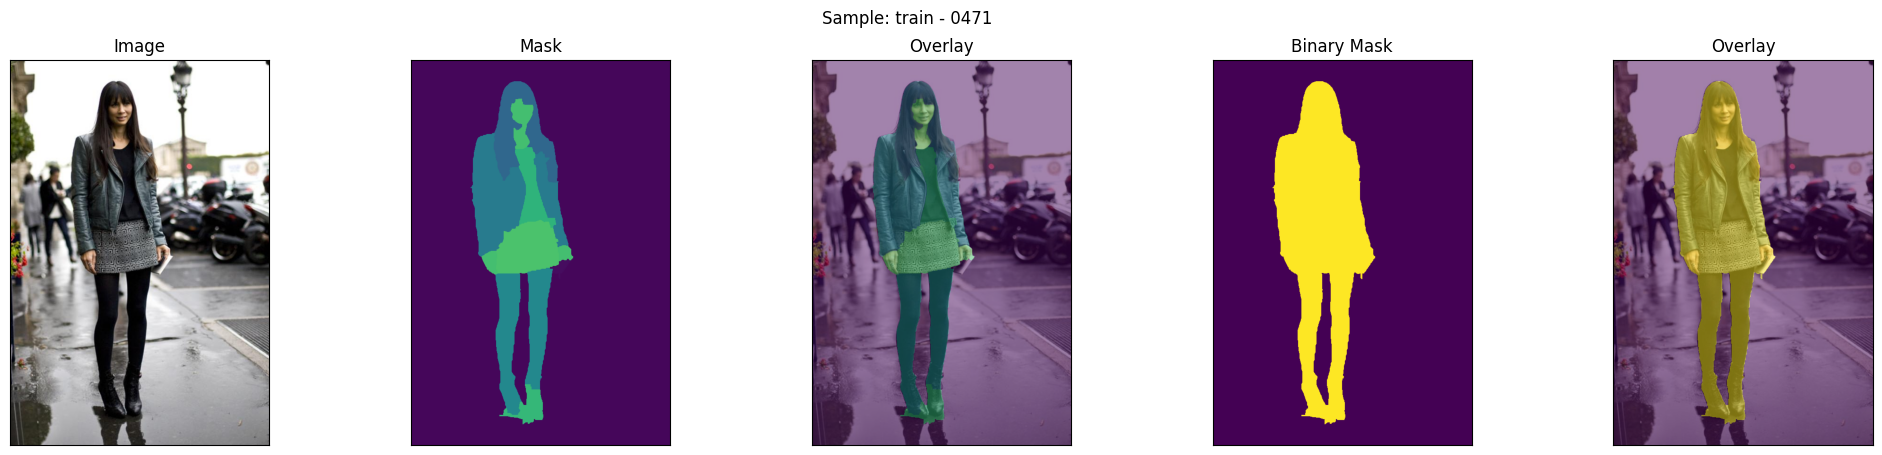

In [78]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

binary_mask = (y != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
ax[3].imshow(binary_mask)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Binary Mask')

ax[4].imshow(x)
ax[4].imshow(binary_mask, alpha=.5)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Overlay')

plt.show()

We start by creating a function that extracts a <span style="color:#D52B29">random patch</span> from an image and assigns it the class corresponding to the <span style="color:#D52B29">central pixel</span> of the patch. It is important to note that, for model training, we will select <span style="color:#D52B29">random patches</span> from the images, since extracting all possible patches corresponding to every pixel in the training images would be <span style="color:#D52B29">computationally infeasible</span>.

In [79]:
def random_crop(img, mask, patch_size=224):
    """
    Take a random [patch_size, patch_size, :] window from an image [H, W, :] and corresponding mask [H, W, :].
    
    Args:
        img: numpy array of shape [H, W, :]
        mask: numpy array of shape [H, W, :]
        patch_size: patch size (int)
    
    Returns:
        img_patch: numpy array of shape [patch_size, patch_size, 3]
        mask_patch: numpy array of shape [patch_size, patch_size, 3]
    """
    H, W, _ = img.shape
        
    # Random top-left corner
    y = np.random.randint(0, H - patch_size + 1)
    x = np.random.randint(0, W - patch_size + 1)
    
    # Extract patch
    img_patch = img[y:y+patch_size, x:x+patch_size, :]
    mask_patch = mask[y:y+patch_size, x:x+patch_size, :]
    
    return img_patch, mask_patch

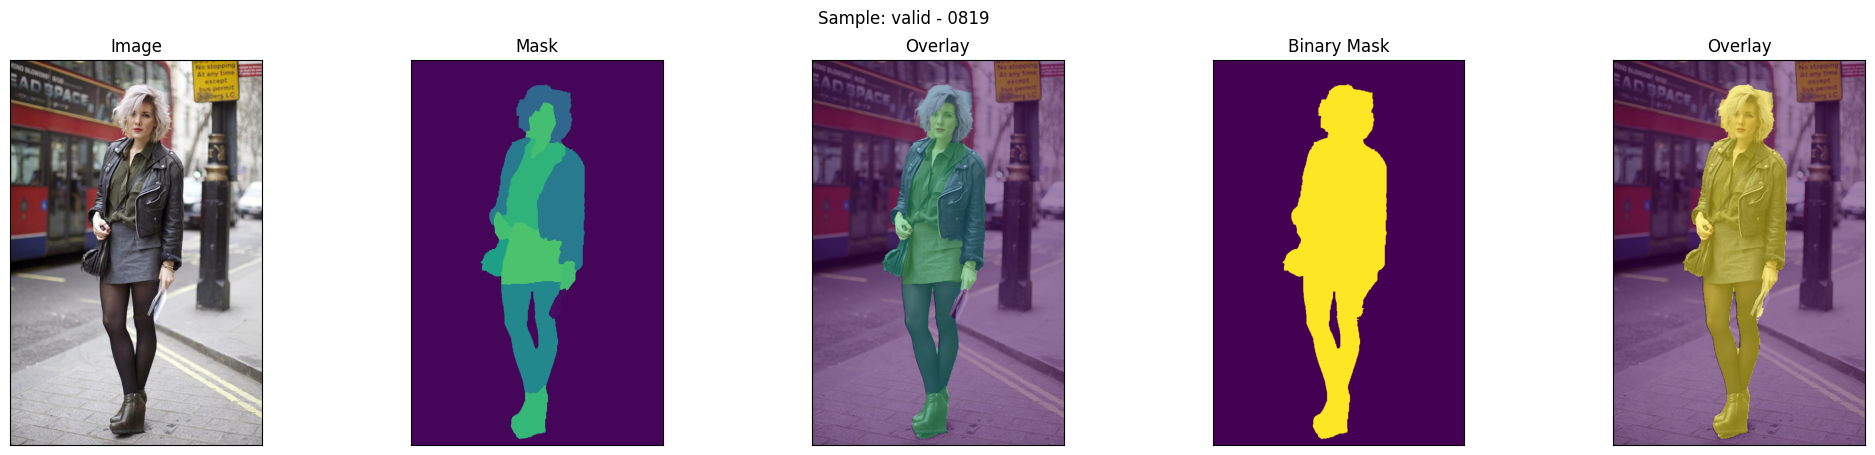

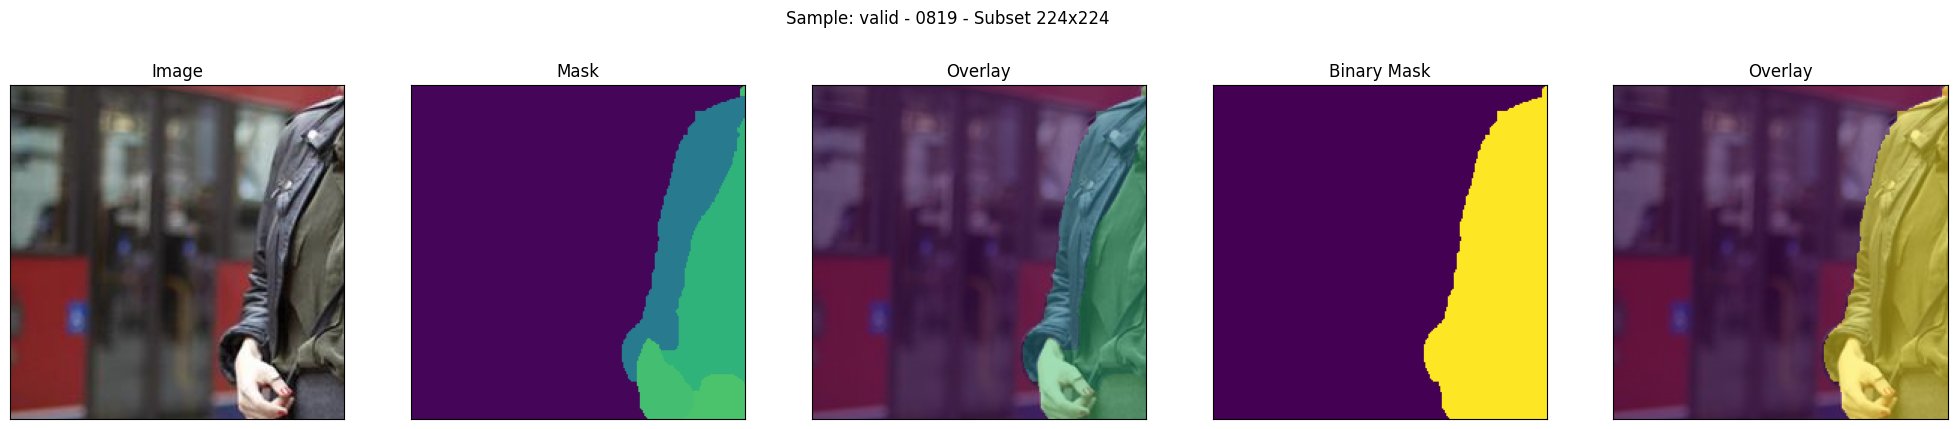

In [80]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

binary_mask = (y != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
ax[3].imshow(binary_mask)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Binary Mask')

ax[4].imshow(x)
ax[4].imshow(binary_mask, alpha=.5)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Overlay')

plt.show()

# Subset

img_patch, mask_patch = random_crop(x, y, patch_size=224)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} - Subset 224x224')

ax[0].imshow(img_patch)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(mask_patch)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(img_patch)
ax[2].imshow(mask_patch, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

binary_mask_patch = (mask_patch != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
ax[3].imshow(binary_mask_patch)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Binary Mask')

ax[4].imshow(img_patch)
ax[4].imshow(binary_mask_patch, alpha=.5)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Overlay')

plt.show()

In [82]:
mask_patch.shape

(224, 224, 3)

What we will do next is create a <span style="color:#D52B29">PyTorch Dataset</span> that takes as input a <span style="color:#D52B29">DataFrame</span> where each row corresponds to one example of the dataset. The <span style="color:#D52B29">getitem()</span> function will load the example at index <span style="color:#D52B29">idx</span>. That is, it will read the image and its corresponding mask, extract a <span style="color:#D52B29">random patch of size 224×224</span>, and then apply transformations to the input image, such as <span style="color:#D52B29">normalization using ImageNet statistics</span>.

In [65]:
import torch

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [83]:
from torchvision.transforms import v2

In [197]:
class CCPDataset(torch.utils.data.Dataset):

    def __init__(self, df, patch_size=224, transforms=None):
        super(CCPDataset, self).__init__()
        self.df = df
        self.ps = patch_size
        self.transforms = transforms

    def __random_crop__(self, img, mask):
        
        H, W, _ = img.shape
            
        # Random top-left corner
        y = np.random.randint(0, H - self.ps + 1)
        x = np.random.randint(0, W - self.ps + 1)
        
        # Extract patch
        img_patch = img[y:y+self.ps, x:x+self.ps, :]
        mask_patch = mask[y:y+self.ps, x:x+self.ps, :]
        
        return img_patch, mask_patch
        
    def __getitem__(self, idx):

        # Take the idx-th row from the DataFrame
        r = self.df.iloc[idx]

        # Read image and mask
        x = imread(r.image_path)
        y = imread(r.mask_path)

        # Take a random patch
        x, y = self.__random_crop__(x, y)

        # Convert into binary mask and take central pixel value
        y = (y != np.array([69,  6, 90])).any(-1)
        y = int(y[self.ps // 2, self.ps // 2])
        
        # Convert to Tensors
        x = torch.from_numpy(x.transpose(2, 0, 1)) # (H, W, C) -> (C, H, W)
        y = torch.tensor([y], dtype=torch.long)

        # Apply transforms
        if self.transforms:
            x = self.transforms(x)
                
        return x, y

    def __show_item__(self, x, y):
        f = plt.figure(figsize=(5, 5))
        plt.imshow(x.permute(1, 2, 0))
        plt.title('Person' if y == 1 else 'Background')
        plt.show()

    def __len__(self): 
        return self.df.shape[0]

In [198]:
from torchvision.models import ResNet18_Weights

In [199]:
weights = ResNet18_Weights.IMAGENET1K_V1
transforms = weights.transforms()
ds = CCPDataset(df, patch_size=224, transforms=transforms)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.343704].


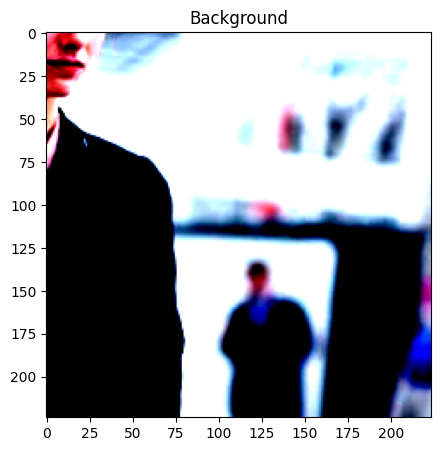

In [200]:
rndm_idx = torch.randint(ds.__len__(), [1]).item()
x, y = ds.__getitem__(rndm_idx)
ds.__show_item__(x, y)

Once we have the <span style="color:#D52B29">Dataset</span>, we can create the <span style="color:#D52B29">DataLoaders</span> using the <span style="color:#D52B29">DataModule</span> class.

In [202]:
import pytorch_lightning as pl

class DataModule(pl.LightningDataModule):
    def __init__(self, df, bs, ps):
        super().__init__()
        self.df = df
        self.bs = bs
        self.ps = ps

    def setup(self, stage): # Data preparation and transforms
        transforms = ResNet18_Weights.IMAGENET1K_V1.transforms()
        self.train_ds = CCPDataset(df=df.query('set == "train"'), patch_size=self.ps, transforms=transforms)
        self.valid_ds = CCPDataset(df=df.query('set == "valid"'), patch_size=self.ps, transforms=transforms)
        self.test_ds = CCPDataset(df=df.query('set == "test"'), patch_size=self.ps, transforms=transforms)

    def train_dataloader(self): return torch.utils.data.DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=8)

    def val_dataloader(self): return torch.utils.data.DataLoader(self.valid_ds, batch_size=self.bs, shuffle=False, num_workers=8)

    def test_dataloader(self): return torch.utils.data.DataLoader(self.test_ds, batch_size=self.bs, shuffle=False, num_workers=8)

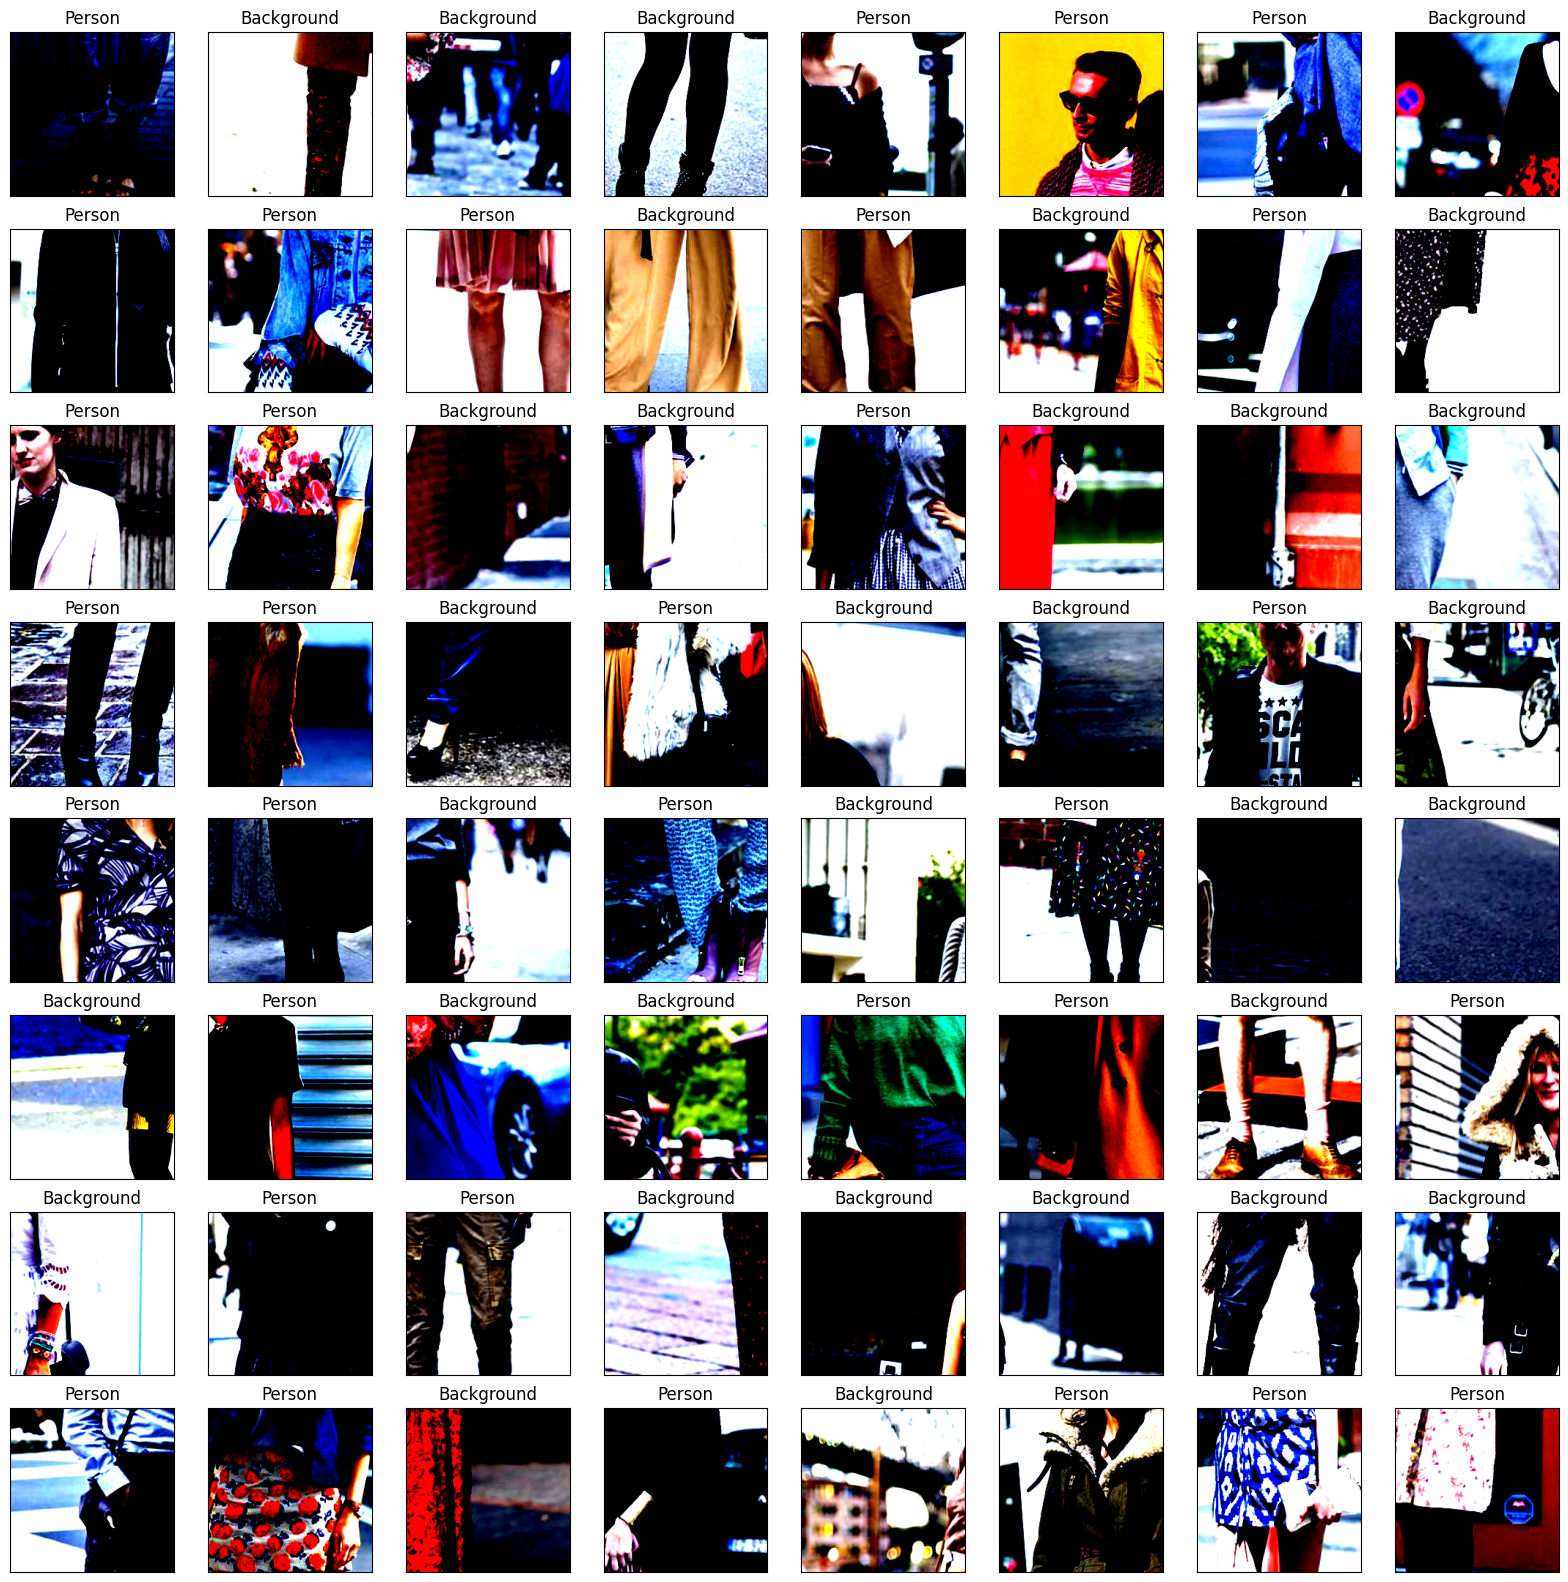

In [203]:
data_module = DataModule(df, bs=64, ps=224)
data_module.setup('test')

train_dataloader = data_module.train_dataloader()

batch = next(iter(train_dataloader))

f, ax = plt.subplots(8, 8, figsize=(20, 20))
ax = ax.ravel()

for i in range(64):
    ax[i].imshow(torch.clip(batch[0][i].permute(1, 2, 0), 0, 1))
    ax[i].set_title('Person' if batch[1][i] == 1 else 'Background')
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show()

Now we will define the <span style="color:#D52B29">model</span>.

In [ ]:
import torch.nn as nn
import torchvision

class SlidingWindowModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Get Pretrained ResNet18 from Torchvision
        self.model = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # Adapt last FC layer for 2 classes (person vs. background)
        num_in_feat = self.model.fc.in_features
        self.model.fc = nn.Linear(num_in_feat, 2)

        # Freeze all layers except the last fully connected
        self.__freeze__()

    def __freeze__(self):
        # Freeze all layers
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze only the last FC layer
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

In [ ]:
model = SlidingWindowModel()
model

In [ ]:
from torch.nn import functional as F
from collections import defaultdict

class LightningModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        
        # Creating model
        self.model = SlidingWindowModel()

        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        
    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.flatten())
        
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.training_step_outputs['loss'] += loss.detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.flatten())
        
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.validation_step_outputs['loss'] += loss.detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return loss

    def on_train_epoch_end(self): 
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        print(f"Average training loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.training_step_outputs.clear() 

    def on_validation_epoch_end(self):
        avg_loss = self.validation_step_outputs['loss'] / self.validation_step_outputs['steps']
        print(f"Average validation loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.validation_step_outputs.clear() 

Once the <span style="color:#D52B29">Dataset</span>, <span style="color:#D52B29">DataModule</span>, <span style="color:#D52B29">Model</span>, and <span style="color:#D52B29">LightningModule</span> are defined, we are ready to start <span style="color:#D52B29">training</span>. We will train the model for <span style="color:#D52B29">30 epochs</span> and save the weights that achieve the best performance on the <span style="color:#D52B29">validation set</span>. As always, we will show the <span style="color:#D52B29">metrics</span> and the evolution of <span style="color:#D52B29">training and validation losses</span>.

In [205]:
from lightning.pytorch.loggers import CSVLogger

# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

# Intantiate LightningModule
lightning_module = LightningModule()

# Define a CSV logger to store training/validation metrics in CSV format.
csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_sliding_window")

# Define a checkpoint callback:
# It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)

# Create a PyTorch Lightning trainer
trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])

# Load the data module
data_module = DataModule(df, bs=64, ps=224)

# Train the model with the trainer, passing the core LightningModule and data module.
trainer.fit(lightning_module, data_module)

Seed set to 42
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name  | Type               | Params | Mode 
-----------------------------------------------------
0 | model | SlidingWindowModel | 11.2 M | train
-----------------------------------------------------
1.0 K     Trainable params
11.2 M    Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Average validation loss for epoch 0: 0.7571


/home/conda/envs/py311/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                                                   …

...

Epoch 28, global step 319: 'val_loss' was not in top 1


Average validation loss for epoch 28: 0.3728
Average training loss for epoch 28: 0.4376


Validation: |                                                                                                 …

Epoch 29, global step 330: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Average validation loss for epoch 29: 0.3643
Average training loss for epoch 29: 0.4254


In [206]:
import pandas as pd

metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
metric_df.head()

,epoch,step,train_loss,val_loss
0,0,10,0.734994,0.643832
1,1,21,0.673266,0.669907
2,2,32,0.605713,0.563833
3,3,43,0.583892,0.566519
4,4,54,0.543920,0.533511


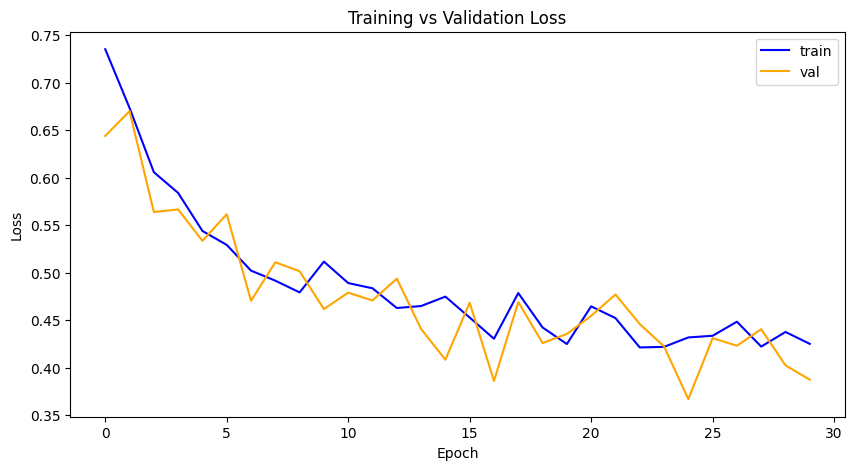

In [207]:
f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.show()

Next, we will load the <span style="color:#D52B29">best model</span> and perform <span style="color:#D52B29">inference</span> on one of the images. To do this, we need to iterate over <span style="color:#D52B29">every single pixel</span> of the image in order to predict its corresponding class. This inference process takes approximately <span style="color:#D52B29">30 minutes per image</span> (the code could be optimized by creating a custom Dataset and working with batches). The main objective here is to observe how this first approach is <span style="color:#D52B29">computationally very expensive</span>.

In [209]:
# Load the best model
model = LightningModule.load_from_checkpoint(model_checkpoint_callback.best_model_path, model=model)
model.cuda(0) # Move to GPU
model.eval()

LightningModule(
  (model): SlidingWindowModel(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

In [214]:
def patch_origins(h, w, ps, overlap=.5):
    """
    Return an array of top-left origins (y, x) for psxps patches over an image of size (h, w)
    with ha given overlap. Ensures coverage of right/bottom edges by adding a
    final origin aligned to h-ps and/or w-ps when needed.

    Args:
        h: image height
        w: image width
        ps: patch size
        overlap: desired overlap between patches

    Returns:
        origins: numpy array of shape (N, 2) with dtype int, rows are (y, x)
        
    """
    
    if ps > h or ps > w:
        raise ValueError("Patch size ps must be <= image dimensions h and w")

    stride = int(ps * overlap)
    if stride <= 0:
        raise ValueError("Patch size too small")

    hs = list(range(0, h - ps + 1, stride))
    ws = list(range(0, w - ps + 1, stride))

    # make sure the last patch touches the image border
    if hs[-1] != h - ps:
        hs.append(h - ps)
    if ws[-1] != w - ps:
        ws.append(w - ps)

    origins = [(h, w) for h in hs for w in ws]
    return np.array(origins, dtype=int)

In [219]:
from fastprogress import master_bar, progress_bar

test_df = df.query('set == "test"')

for i, r in test_df.iterrows():
    
    # Read image and mask
    x = imread(r.image_path)
    y = imread(r.mask_path)
    
    # Convert into binary mask and take central pixel value
    y = (y != np.array([69,  6, 90])).any(-1)
    
    # Pad x half the patch size to make it possible for edge pixels to have enough context
    patch_size = 224
    pad = patch_size // 2
    padded_x = np.pad(x, pad_width=((pad, pad), (pad, pad), (0, 0)), mode='constant')
    
    # Iterate over all pixels
    h, w, _ = padded_x.shape
    padded_y_hat_logits = torch.zeros((h, w, 2), dtype=torch.float32)
    
    mb = master_bar(range(pad, h-pad))
    for i in mb:
        for j in progress_bar(range(pad, w-pad), parent=mb):
            xij = padded_x[i-pad:i+pad, j-pad:j+pad]
            xij = torch.from_numpy(xij.transpose(2, 0, 1)) # (H, W, C) -> (C, H, W)
            xij = ResNet18_Weights.IMAGENET1K_V1.transforms()(xij)
    
            with torch.no_grad():
                logits = model(xij.unsqueeze(0).cuda())
                logits = nn.Softmax(1)(logits).detach().cpu()
                padded_y_hat_logits[i-pad:i+pad, j-pad:j+pad] += logits

    break # Just infere one image

In [246]:
h, w, _ = padded_x.shape
padded_y_hat_logits = torch.zeros((h, w, 2), dtype=torch.float32)

mb = master_bar(range(pad, h-pad))
for i in mb:
    for j in progress_bar(range(pad, w-pad), parent=mb):
        xij = padded_x[i-pad:i+pad, j-pad:j+pad]
        xij = torch.from_numpy(xij.transpose(2, 0, 1)) # (H, W, C) -> (C, H, W)
        xij = ResNet18_Weights.IMAGENET1K_V1.transforms()(xij)

        with torch.no_grad():
            logits = model(xij.unsqueeze(0).cuda())
            logits = nn.Softmax(1)(logits).detach().cpu()
            padded_y_hat_logits[i-pad:i+pad, j-pad:j+pad] += logits
            

Epoch 827/827 :                                                                         

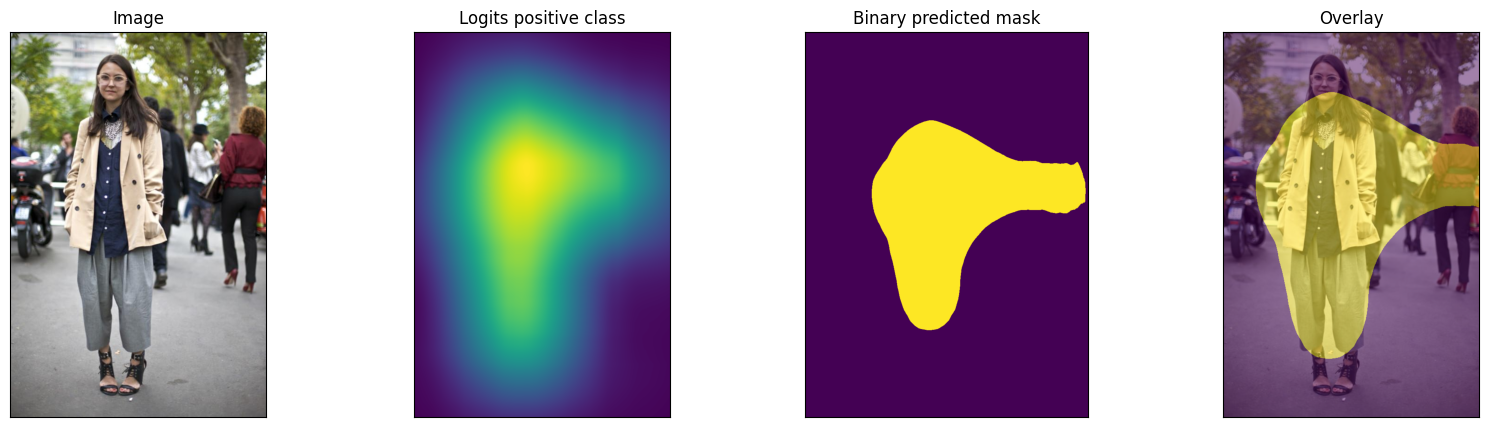

In [256]:
y_hat = padded_y_hat_logits.argmax(-1)

f, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(padded_y_hat_logits[pad:-pad, pad:-pad, 1])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Logits positive class')

ax[2].imshow(y_hat)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Binary predicted mask')

ax[3].imshow(x)
ax[3].imshow(y_hat[pad:-pad, pad:-pad], alpha=.5)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Overlay')

plt.show()

As we can see, the result is not completely bad, although it is far from perfect. The main issue with this strategy is its <span style="color:#D52B29">inefficiency</span>: we need to classify <span style="color:#D52B29">each pixel separately</span>, and to do so we are using relatively large patches. The whole process takes about <span style="color:#D52B29">30 minutes per image</span>!!!

If we think carefully, what is happening here is that when classifying two contiguous pixels, a large part of the internal processing of the network is repeated, since many neighboring pixels are the same and therefore their <span style="color:#D52B29">feature extraction</span> is redundantly computed. This leads to an inefficient process that could be optimized by <span style="color:#D52B29">reusing the features</span> among overlapping patches.

We will explore this optimization in the next section, but before that, let’s take a short pause to discuss the <span style="color:#D52B29">evaluation metrics</span> used in semantic segmentation. This will allow us to properly compare this approach with the alternatives that follow.

## <span style="color:#D52B29">Evaluation metrics in semantic segmentation</span>

In <span style="color:#D52B29">semantic segmentation</span>, we can still use some of the metrics seen in classification, such as <span style="color:#D52B29">accuracy</span> or the <span style="color:#D52B29">percentage of correctly classified pixels</span>.

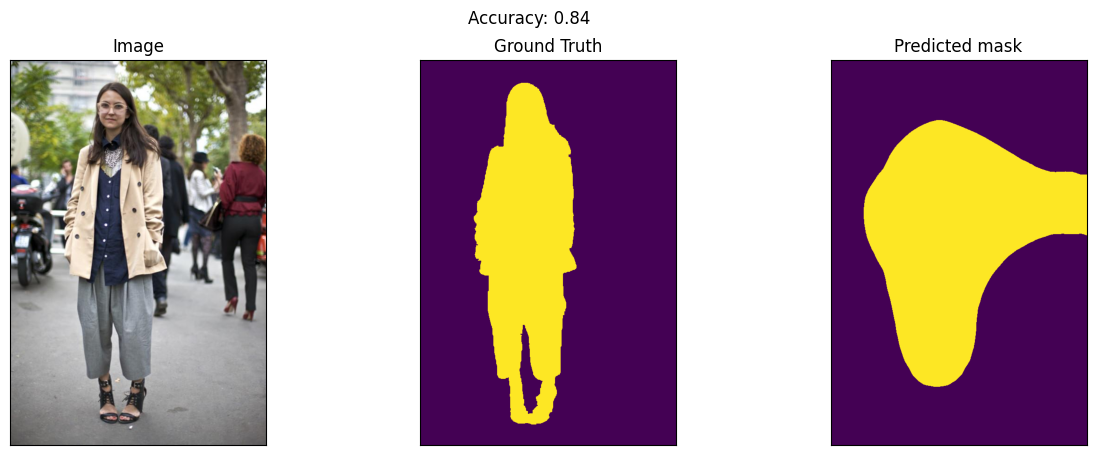

In [310]:
from sklearn.metrics import accuracy_score

y_hat = padded_y_hat_logits.argmax(-1)[pad:-pad, pad:-pad]

acc = accuracy_score(y_hat.ravel(), y.ravel())

f, ax = plt.subplots(1, 3, figsize=(15, 5))

f.suptitle(f'Accuracy: {acc:.2f}')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Predicted mask')

plt.show()

However, we are already aware of some of the problems that <span style="color:#D52B29">accuracy</span> can have, for example when working with <span style="color:#D52B29">imbalanced problems</span>. In semantic segmentation, it is common to use two other metrics that measure how well the <span style="color:#D52B29">predicted mask</span> matches the <span style="color:#D52B29">ground truth mask</span>.

- <span style="color:#D52B29">Intersection over Union (IoU)</span>
- <span style="color:#D52B29">Dice Coefficient / F1-score</span>

Undoubtedly, the most widely used metric is <span style="color:#D52B29">IoU</span> (Intersection over Union). It basically measures the number of <span style="color:#D52B29">pixels shared</span> between the two masks divided by the total number of pixels predicted as positive in both masks.

<span style="color:#D52B29">Note:</span> In the case of multiple classes, the <span style="color:#D52B29">IoU</span> is calculated for each class individually and then their mean is computed. This metric is known as <span style="color:#D52B29">mean IoU (mIoU)</span>.

Next, we will try to illustrate this metric using the results from the previous test.

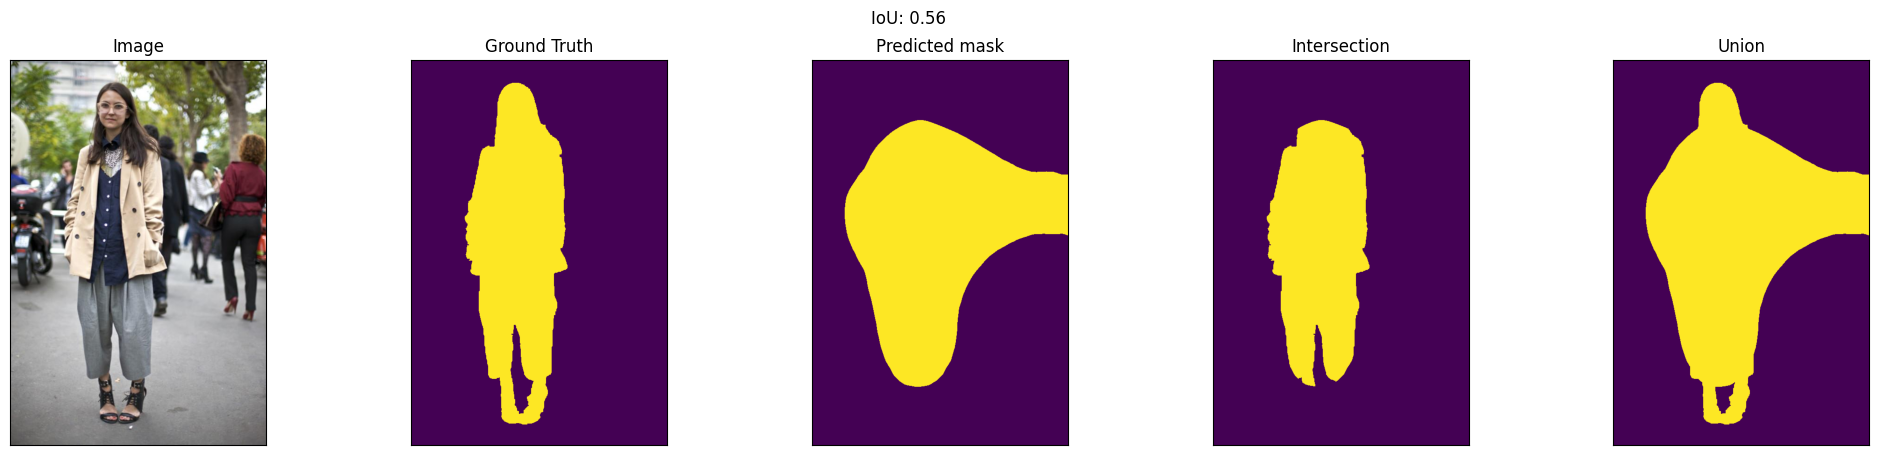

In [265]:
f, ax = plt.subplots(1, 5, figsize=(25, 5))

intersection = np.logical_and(y, y_hat).numpy()
union = np.logical_or(y, y_hat).numpy()

iou = np.sum(intersection) / np.sum(union)

f.suptitle(f'IoU: {iou:.2f}')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Predicted mask')

ax[3].imshow(intersection)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Intersection')

ax[4].imshow(union)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Union')

plt.show()

As we can see, <span style="color:#D52B29">IoU</span> is a <span style="color:#D52B29">strict metric</span>, in the sense that small errors can significantly penalize the score. The <span style="color:#D52B29">maximum value</span> it can take is 1, while the <span style="color:#D52B29">minimum</span> is 0.

Finally, as with other metrics, it is not necessary to calculate <span style="color:#D52B29">IoU</span> manually, since we can use the <span style="color:#D52B29">jaccard_score</span>
 function from scikit-learn, which is equivalent to IoU (the name used depends on the application domain).

<span style="color:#D52B29">Note:</span> To compute the metric, the masks must be passed as <span style="color:#D52B29">flattened vectors</span>.

In [267]:
from sklearn.metrics import jaccard_score
iou = jaccard_score(y_hat.ravel(), y.ravel())
print(f'IoU {iou:.2f}')

IoU 0.56


The other widely used metric in <span style="color:#D52B29">semantic segmentation</span> is the <span style="color:#D52B29">Dice score</span>. We are already familiar with this metric, as in classification it corresponds to the <span style="color:#D52B29">F1-score</span>. If we look closely, we can see that its formulation is very similar to that of <span style="color:#D52B29">IoU</span>. In fact, both are correlated and one can be calculated from the other ([recommended reading on StackExchange](https://stats.stackexchange.com/a/276144)):

$$
\text{Dice} = \frac{2 \cdot \text{IoU}}{\text{IoU} + 1}
$$

Depending on how the metrics are averaged across all examples, there can be differences between using one or the other, as <span style="color:#D52B29">IoU</span> tends to penalize more heavily the severe errors.

In [276]:
dice = np.sum(2 * intersection) / (np.sum(y) + np.sum(y_hat.numpy()))
print(f'Dice {dice:.4f}')

Dice 0.7144


In [277]:
dice = (2 * iou) / (iou + 1)
print(f'Dice {dice:.4f}')

Dice 0.7144


In [278]:
from sklearn.metrics import f1_score
dice = f1_score(y_hat.ravel(), y.ravel())
print(f'Dice {dice:.4f}')

Dice 0.7144


<span style="color:#D52B29">General note on metrics:</span> When we want to compute metrics for multiple images, it is most common to calculate the metric for <span style="color:#D52B29">each image individually</span> and then compute the <span style="color:#D52B29">mean value</span> across all images. The same applies to <span style="color:#D52B29">loss functions</span>.

Finally, since these metrics are calculated from the elements of the <span style="color:#D52B29">confusion matrix</span> (true positives, false positives, etc.), we can compute <span style="color:#D52B29">masks</span> for each element and visualize them. This allows us to <span style="color:#D52B29">see where the model is correct or failing</span>, which can provide insights into how to <span style="color:#D52B29">improve its performance</span>.

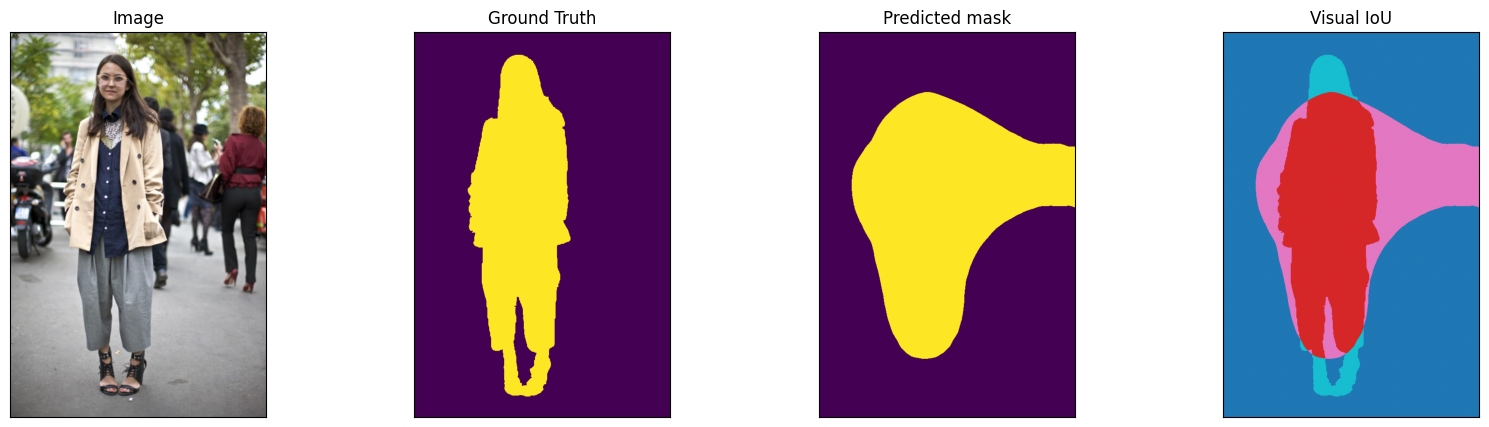

In [302]:
tp = np.logical_and(y, y_hat).numpy().astype(bool)
fp = np.logical_and(~y, y_hat == 1).numpy().astype(bool)
fn = np.logical_and(y, y_hat==0).numpy().astype(bool)

visual_iou = np.zeros_like(y, dtype='uint8')
visual_iou[tp] = 1
visual_iou[fp] = 2
visual_iou[fn] = 3

f, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Predicted mask')

ax[3].imshow(visual_iou, vmin=0, vmax=3, cmap=plt.cm.tab10)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Visual IoU')

plt.show()

Returning to the previous experiment, we will calculate these <span style="color:#D52B29">metrics</span> as well as the <span style="color:#D52B29">inference time</span>. This will allow us to compare it with the two strategies we still have to explore. In this case, due to the <span style="color:#D52B29">high inference time</span>, we will only compute the metrics for the <span style="color:#D52B29">first image</span>.

In [309]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score

acc  = accuracy_score(y_hat.ravel(), y.ravel())
iou  = jaccard_score(y_hat.ravel(), y.ravel())
dice = f1_score(y_hat.ravel(), y.ravel())

print(f'Pixel Accuracy  {acc*100:.2f}')
print(f'IoU              {iou:.2f}')
print(f'Dice             {dice:.2f}')
print(f'Inf. time      ~30min')

Pixel Accuracy  83.89
IoU              0.56
Dice             0.71
Inf. time      ~30min


## <span style="color:#D52B29">Fully Convolutional Networks (FCNNs)</span>

As we have seen, the previous approach, although relatively accurate for the current problem, is <span style="color:#D52B29">computationally unfeasible</span> due to the large number of repeated operations. Therefore, it is necessary to explore alternative strategies.

An intuitive idea would be to have the <span style="color:#D52B29">CNN output a mask</span> the same size as the input image. We could attempt this directly from the last convolutional layer of the ResNet we used, but the problem is that most networks use <span style="color:#D52B29">pooling</span> to reduce the dimensions of the feature maps they operate on, which also allows a more global view of the image. Trying to reconstruct a precise mask from this point does not seem optimal.

This is where the concept of <span style="color:#D52B29">Fully Convolutional Neural Networks (FCNNs)</span> comes into play. In these networks, <span style="color:#D52B29">pooling layers are avoided</span> so that the output has the <span style="color:#D52B29">same dimensions as the input</span>, allowing us to produce a <span style="color:#D52B29">full-image mask</span> as output. This solves the problem of repeated computations that we encountered with the patch-based strategy.

If we analyze this approach, we quickly realize that it also has <span style="color:#D52B29">limitations</span>. Operating on the <span style="color:#D52B29">full image dimensions</span> throughout the network makes the computations very expensive. Therefore, using <span style="color:#D52B29">deep networks with many convolutional layers</span> also becomes challenging. Nevertheless, we are going to test it and see the results.

The first thing we will do is modify the dataset so that, instead of returning the <span style="color:#D52B29">class of the central pixel</span>, it returns the <span style="color:#D52B29">mask corresponding to the 224×224 window</span> that we randomly extracted.

In this case, we need to modify both the <span style="color:#D52B29">input image</span> and the <span style="color:#D52B29">ground truth mask</span> in the same way (except for normalization). For example, if we apply augmentations (so far we have not) and rotate the image by 90 degrees, we must also rotate the mask by 90 degrees to keep them aligned.

Moreover, the <span style="color:#D52B29">224×224 crop</span> can also be performed using the <span style="color:#D52B29">torchvision transformations</span>. To apply them simultaneously to both the image and the mask, we need an intermediate step: converting them into the <span style="color:#D52B29">PIL format</span>.

It is worth stressing that although for training random patches suffice, for evaluation (validation and testing sets) we need to consider all the <span style="color:#D52B29">224×224 patches</span> within the images discretely, so that every epoch we evaluate the model on the exact same patches. To achieve this, we need to slightly modify the behavior of our <span style="color:#D52B29">Dataset class</span>.

First, we will introduce a parameter <span style="color:#D52B29">mode</span>, which will indicate whether we are training or evaluating. If in training mode, the Dataset will work as before (sampling random patches). However, if in evaluation mode, the Dataset will rely on an additional <span style="color:#D52B29">coordinates column</span> in the dataframe, which specifies the location from which to crop the image.

Later, in the <span style="color:#D52B29">DataModule</span>, we will compute for each image all the coordinates of the non-overlapping <span style="color:#D52B29">224×224 tiles</span> (all possible windows that fully cover the image). This results in a list of coordinates per image, which we will then expand into individual rows (one per coordinate). Consequently, the evaluation dataframe will contain as many rows as <span style="color:#D52B29">images × coordinates</span>.

In summary, each row in the evaluation dataframe will now include not only the <span style="color:#D52B29">image and mask paths</span> as usual, but also an additional column containing a tuple of <span style="color:#D52B29">coordinates</span> that indicates the region to crop.

In [627]:
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms.v2 as T

# ImageNet transforms + RandomCrop 
image_and_mask_transforms = T.Compose([
    T.RandomCrop((224, 224)),
    T.Resize(size=(256, 256)),
])

image_only_transforms = T.Compose([
    T.ToImage(),                               
    T.ToDtype(torch.float32, scale=True),      
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]), 
])

class CCPDataset(torch.utils.data.Dataset):

    def __init__(self, df, patch_size=224, transforms=None, mode='train'):
        super(CCPDataset, self).__init__()
        self.df = df
        self.ps = patch_size
        self.transforms = transforms
        self.mode = mode
        
    def __getitem__(self, idx):

        # Take the idx-th row from the DataFrame
        r = self.df.iloc[idx]

        # Read image and mask
        x = imread(r.image_path)
        y = imread(r.mask_path)

        # Convert into binary mask
        y = (y != np.array([69,  6, 90])).any(-1)

        if self.mode == 'eval': # If we are evaluating (valid or test set) perform a subset based on the given coordinates
            x = x[r.coords[0]:r.coords[0]+self.ps, r.coords[1]:r.coords[1]+self.ps]
            y = y[r.coords[0]:r.coords[0]+self.ps, r.coords[1]:r.coords[1]+self.ps]
                    
        # Convert to PIL image. Converting to PIL before calling the v2 transforms makes the behavior consistent across torchvision versions.
        x = to_pil_image(x.astype('float32'))
        y = to_pil_image(y.astype('uint8'), mode='L')
        
        # Apply transforms
        if self.transforms:
            x, y = self.transforms[0](x, y) # First, transforms for both image and mask synchronized
            x = self.transforms[1](x) # Second, tranforms for only images

        # PIL to Tensor
        y = (torchvision.transforms.functional.to_tensor(y) > 0).type(torch.long)
            
        return x, y

    def __show_item__(self, x, y):
        f, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(x.permute(1, 2, 0))
        ax[0].set_title('Image')
        ax[0].set_xticks([])
        ax[0].set_yticks([])

        ax[1].imshow(y[0])
        ax[1].set_title('Mask')
        ax[1].set_xticks([])
        ax[1].set_yticks([])

        ax[2].imshow(x.permute(1, 2, 0))
        ax[2].imshow(y[0], alpha=.5, vmin=0, vmax=1)
        ax[2].set_title('Overlay')
        ax[2].set_xticks([])
        ax[2].set_yticks([])

        plt.show()
        

    def __len__(self): 
        return self.df.shape[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.500567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.500567].


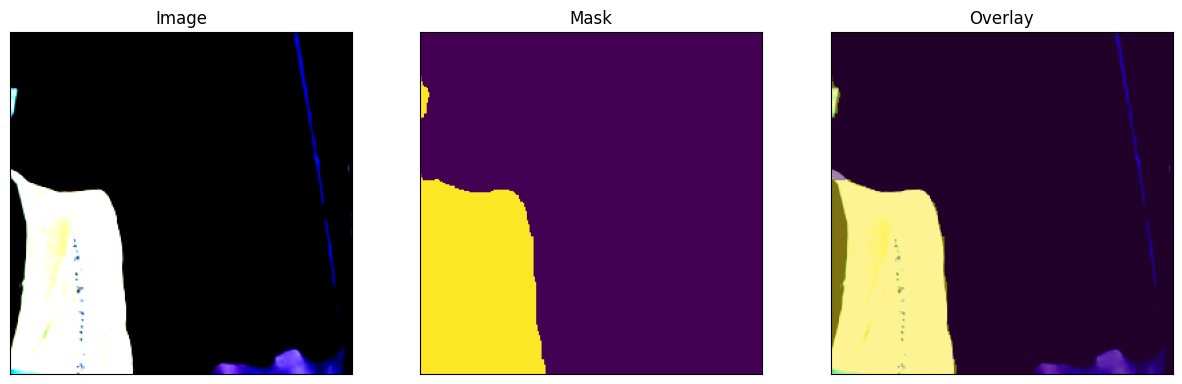

In [628]:
ds = CCPDataset(df, patch_size=224, transforms=(image_and_mask_transforms, image_only_transforms), mode='train')

rndm_idx = torch.randint(ds.__len__(), [1]).item()
x, y = ds.__getitem__(rndm_idx)

ds.__show_item__(x, y)

As we mentioned earlier, in the <span style="color:#D52B29">DataModule</span> we need to generate, for each image, the list of coordinates corresponding to the <span style="color:#D52B29">224×224 tiles</span> on which we will evaluate the model. To do so, we will use the function <span style="color:#D52B29">patch_origins()</span> that we defined previously.

Once we obtain this list of coordinates, we will expand the dataset, creating as many rows as <span style="color:#D52B29">image–coordinate</span> combinations exist. We will instantiate the datasets that need this evaluation procedure (validation and test) using these “new” datasets and setting the <span style="color:#D52B29">mode</span> parameter of the <span style="color:#D52B29">Dataset</span> accordingly.

Finally, in the transformations for these evaluation datasets we will remove the <span style="color:#D52B29">random cropping</span>, since the coordinates are now explicitly provided.


In [629]:
import pytorch_lightning as pl

class DataModule(pl.LightningDataModule):
    def __init__(self, df, bs, ps):
        super().__init__()
        self.df = df
        self.bs = bs
        self.ps = ps

    def patch_origins(self, h, w, ps, overlap=.5):
    
        if ps > h or ps > w:
            raise ValueError("Patch size ps must be <= image dimensions h and w")
    
        stride = int(ps * overlap)
        if stride <= 0:
            raise ValueError("Patch size too small")
    
        hs = list(range(0, h - ps + 1, stride))
        ws = list(range(0, w - ps + 1, stride))
    
        # make sure the last patch touches the image border
        if hs[-1] != h - ps:
            hs.append(h - ps)
        if ws[-1] != w - ps:
            ws.append(w - ps)
    
        origins = [(h, w) for h in hs for w in ws]
        return np.array(origins, dtype=int)

    def setup(self, stage): # Data preparation and transforms

        train_transforms = (
            T.Compose([
                T.RandomCrop((224, 224)),
                T.Resize(size=(256, 256)),                
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )

        eval_transforms = (
            T.Compose([
                T.Resize(size=(256, 256)),    
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )
        
        self.train_ds = CCPDataset(df=self.df.query('set == "train"'), patch_size=self.ps, transforms=train_transforms)

        valid_df = self.df.query('set == "valid"')
        valid_df['coords'] = valid_df.image_path.apply(lambda x : self.patch_origins(*imread(x).shape[:-1], ps=224, overlap=1).tolist())
        valid_df = valid_df.explode('coords')

        test_df = self.df.query('set == "test"')
        test_df['coords'] = test_df.image_path.apply(lambda x : self.patch_origins(*imread(x).shape[:-1], ps=224, overlap=1).tolist())
        test_df = test_df.explode('coords')
        
        self.valid_ds = CCPDataset(df=valid_df, patch_size=self.ps, transforms=eval_transforms, mode='eval')
        self.test_ds = CCPDataset(df=test_df, patch_size=self.ps, transforms=eval_transforms, mode='eval')

    def train_dataloader(self): return torch.utils.data.DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=8)

    def val_dataloader(self): return torch.utils.data.DataLoader(self.valid_ds, batch_size=self.bs, shuffle=False, num_workers=8)

    def test_dataloader(self): return torch.utils.data.DataLoader(self.test_ds, batch_size=self.bs, shuffle=False, num_workers=8)
	

/tmp/ipykernel_84521/1450964625.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['coords'] = valid_df.image_path.apply(lambda x : self.patch_origins(*imread(x).shape[:-1], ps=224, overlap=1).tolist())
/tmp/ipykernel_84521/1450964625.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['coords'] = test_df.image_path.apply(lambda x : self.patch_origins(*imread(x).shape[:-1], ps=224, overlap=1).tolist())
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or 

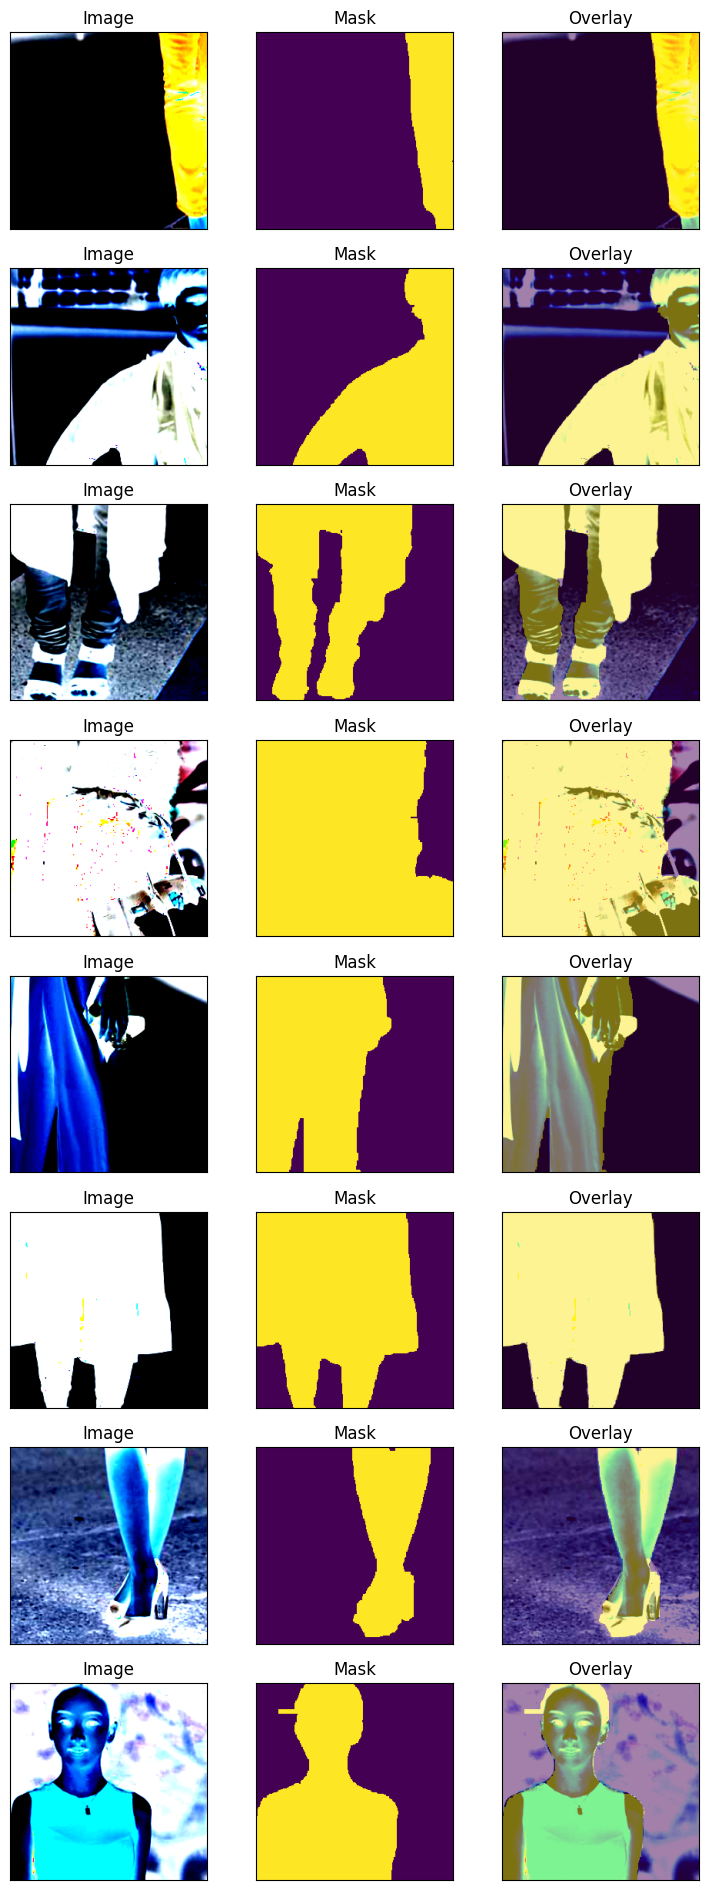

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4308503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4308503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


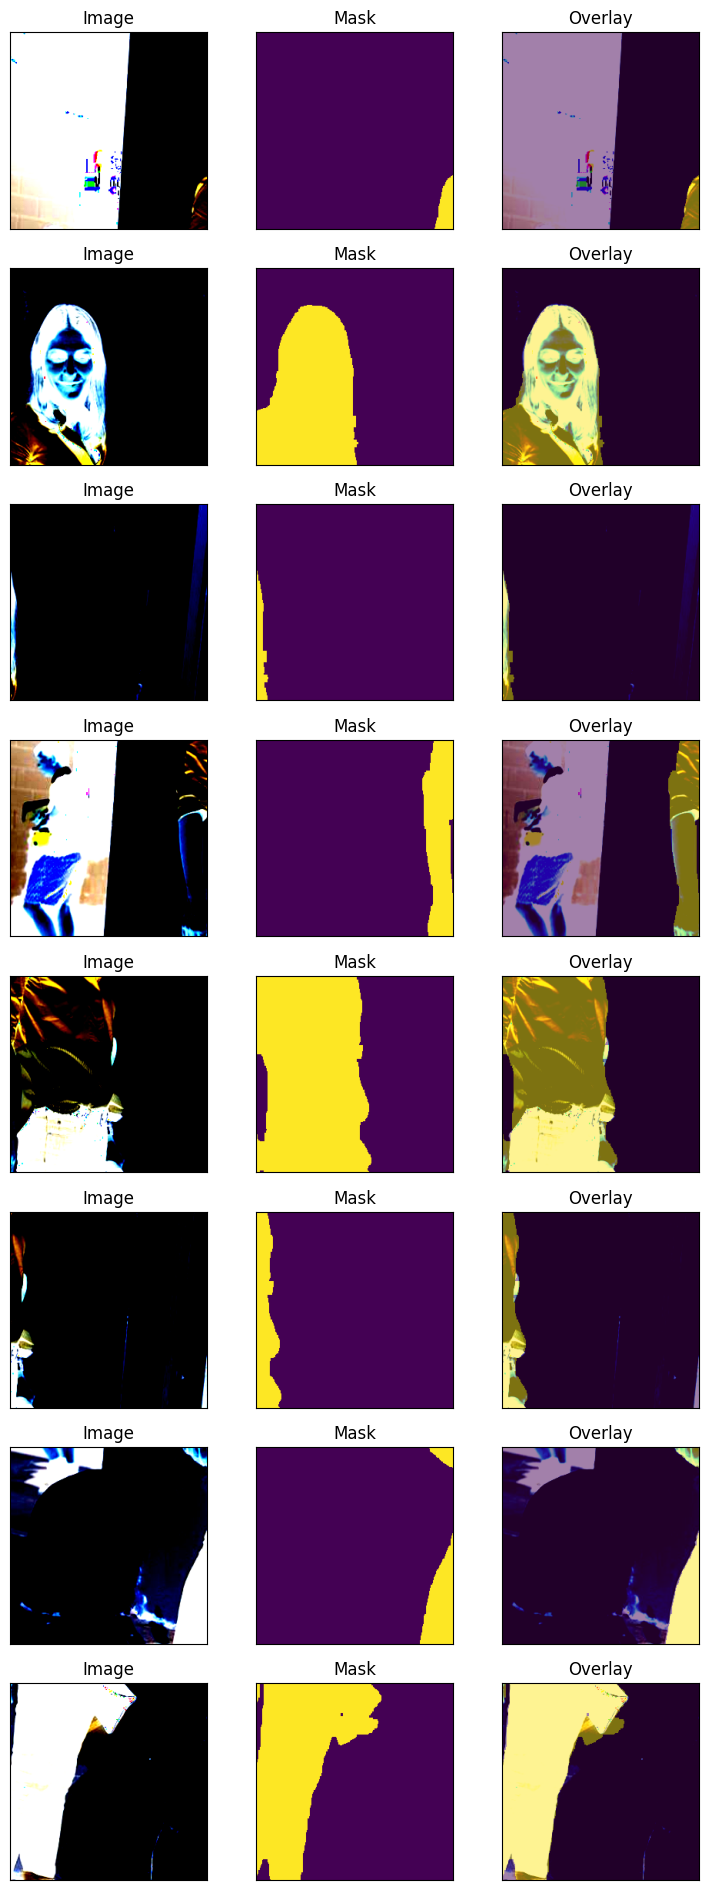

In [630]:
data_module = DataModule(df, bs=8, ps=224)
data_module.setup('test')

train_dataloader = data_module.train_dataloader()
batch = next(iter(train_dataloader))

x, y = batch
bs = x.shape[0]
f, ax = plt.subplots(bs, 3, figsize=(9, bs*3))
for i in range(bs):
    ax[i][0].imshow(x[i].permute(1, 2, 0))
    ax[i][0].set_xticks([])
    ax[i][0].set_yticks([])
    ax[i][0].set_title('Image')

    ax[i][1].imshow(y[i][0])
    ax[i][1].set_xticks([])
    ax[i][1].set_yticks([])
    ax[i][1].set_title('Mask')

    ax[i][2].imshow(x[i].permute(1, 2, 0))
    ax[i][2].imshow(y[i][0], alpha=.5)
    ax[i][2].set_xticks([])
    ax[i][2].set_yticks([])
    ax[i][2].set_title('Overlay')

plt.show()

valid_dataloader = data_module.val_dataloader()
batch = next(iter(valid_dataloader))

x, y = batch
bs = x.shape[0]
f, ax = plt.subplots(bs, 3, figsize=(9, bs*3))
for i in range(bs):
    ax[i][0].imshow(x[i].permute(1, 2, 0))
    ax[i][0].set_xticks([])
    ax[i][0].set_yticks([])
    ax[i][0].set_title('Image')

    ax[i][1].imshow(y[i][0])
    ax[i][1].set_xticks([])
    ax[i][1].set_yticks([])
    ax[i][1].set_title('Mask')

    ax[i][2].imshow(x[i].permute(1, 2, 0))
    ax[i][2].imshow(y[i][0], alpha=.5)
    ax[i][2].set_xticks([])
    ax[i][2].set_yticks([])
    ax[i][2].set_title('Overlay')

plt.show()

While the <span style="color:#D52B29">training dataset</span> generates random <span style="color:#D52B29">224×224 patches</span> from each image, the <span style="color:#D52B29">validation</span> and <span style="color:#D52B29">test datasets</span> systematically cover all possible <span style="color:#D52B29">224×224 patches without overlap</span>.

Once the <span style="color:#D52B29">Datasets</span> and <span style="color:#D52B29">DataModule</span> are defined, we proceed to implement the model: a <span style="color:#D52B29">Fully Convolutional Neural Network (FCN)</span>. For simplicity, we will build a very lightweight architecture, entirely convolutional, where the number of convolutional blocks can be adjusted through the parameter <span style="color:#D52B29">n_blocks</span>.


In [631]:
class FCN(nn.Module):

    def __init__(self, n_class, n_blocs):
        super().__init__()
        self.n_class = n_class
        self.n_blocs = n_blocs
        
        k_size = 16
        layers = [nn.Conv2d(3, k_size, 3, 1, 1)]
        for i in np.arange(1, n_blocs):
            layers += [nn.ReLU(inplace=True), 
                       nn.Conv2d(k_size, k_size, 3, 1, 1), 
                       nn.BatchNorm2d(k_size)] 
        layers += [nn.ReLU(inplace=True), 
                   nn.Conv2d(k_size, k_size, 3, 1, 1), 
                   nn.Conv2d(k_size, n_class, 3, 1, 1)]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

The parameter <span style="color:#D52B29">n_class</span> determines the number of neurons in the <span style="color:#D52B29">final layer</span>, i.e., the number of target classes. In this case, we can choose either 1 or 2. Depending on the choice, we must use a different <span style="color:#D52B29">loss function</span>: <span style="color:#D52B29">Binary Cross Entropy</span> for 1 class, or <span style="color:#D52B29">Cross Entropy</span> for 2 classes.

Here, we will use 2 neurons to remain consistent with the first experiment. When we instantiate the model and pass a random test example, we observe that it returns a <span style="color:#D52B29">predicted segmentation mask</span> with the same dimensions as the original image, which is precisely what we aimed to achieve with the <span style="color:#D52B29">FCNs</span>.


In [632]:
model = FCN(n_class=2, n_blocs=8)

x = torch.rand(1, 3, 256, 256)
y_hat = model(x)
y_hat.shape

torch.Size([1, 2, 256, 256])

Finally, we need to adapt the <span style="color:#D52B29">LightningModule</span> to work with the <span style="color:#D52B29">FCN</span> we just defined and for <span style="color:#D52B29">semantic segmentation tasks</span>. This involves modifying the way the <span style="color:#D52B29">loss function</span> is computed to account for per-pixel classification.


In [633]:
from torch.nn import functional as F
from collections import defaultdict

class LightningModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        
        # Creating model
        self.model = FCN(n_class=2, n_blocs=8)

        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        
    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1)) # y: (BS, 1, H, W) -> (BS, H, W)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.training_step_outputs['loss'] += loss.detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1))
        
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.validation_step_outputs['loss'] += loss.detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return loss

    def on_train_epoch_end(self): 
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        print(f"Average training loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.training_step_outputs.clear() 

    def on_validation_epoch_end(self):
        avg_loss = self.validation_step_outputs['loss'] / self.validation_step_outputs['steps']
        print(f"Average validation loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.validation_step_outputs.clear() 
		

Now, we have all the necessary components to <span style="color:#D52B29">train the model</span>. Let’s go ahead.

In [ ]:
from lightning.pytorch.loggers import CSVLogger

# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

# Intantiate LightningModule
lightning_module = LightningModule()

# Define a CSV logger to store training/validation metrics in CSV format.
csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_fcn")

# Define a checkpoint callback:
# It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)

# Create a PyTorch Lightning trainer
trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])

# Load the data module
data_module = DataModule(df, bs=64, ps=224)

# Train the model with the trainer, passing the core LightningModule and data module.
trainer.fit(lightning_module, data_module)

   epoch  step  train_loss  val_loss
0      0    10    0.594015  0.533114
1      1    21    0.484336  0.455095
2      2    32    0.485410  0.395075
3      3    43    0.476798  0.518880
4      4    54    0.467235  0.608766


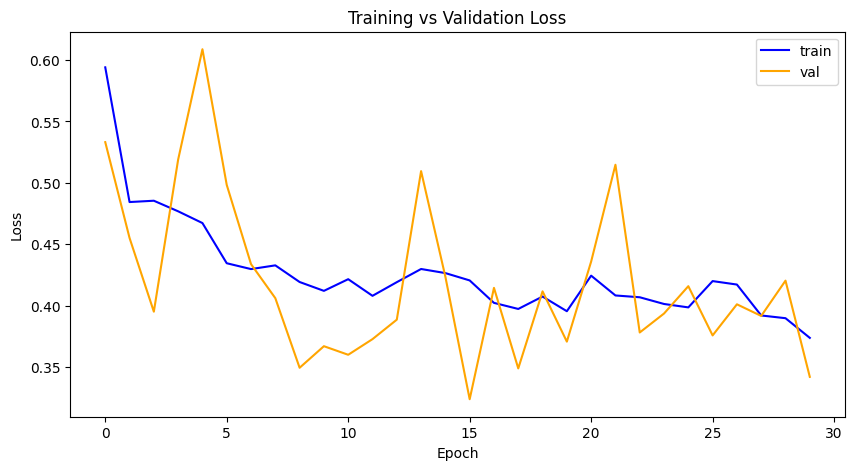

In [634]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.show()

We will now load the best model and perform inference as before, in order to compute metrics and compare this approach with the previous one.

In [645]:
# Load the best model
model = LightningModule.load_from_checkpoint(model_checkpoint_callback.best_model_path, model=model)
model.cuda(0) # Move to GPU
model.eval()

LightningModule(
  (model): FCN(
    (model): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): ReLU(inplace=True)
      (5): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): ReLU(inplace=True)
      (8): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (12): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): ReLU(inplace=True)
      (14): Conv2d(16, 16, kernel_size=(

In [649]:
ps = 256 # Imagenet Resizes to 256

inf_transforms = T.Compose([
    # T.Resize(size=(256, 256)),    
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

metric_dict = []

test_df = df.query('set == "test"')

mb = master_bar(test_df.iterrows(), total=test_df.shape[0])

for i, r in mb:

    # Read image and mask
    x = imread(r.image_path)
    y = imread(r.mask_path)
    
    # Convert into binary mask and take central pixel value
    y = (y != np.array([69,  6, 90])).any(-1)
    
    # Compute origins
    h, w = y.shape
    coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()

    # Initialize y_hat
    y_hat = torch.zeros((2, h, w), dtype=torch.float32)
    y_wei = torch.zeros((1, h, w), dtype=torch.uint8) # Times each pixel has been infered
    
    # Perform inference
    for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            
        # Crop
        xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
        
        # Convert to PIL image.
        xi = to_pil_image(xi.astype('float32'))
        
        # Apply transforms
        xi = inf_transforms(xi)

        # Forward
        with torch.no_grad():
            logits = model(xi.cuda(0).unsqueeze(0))
            logits = nn.Softmax(1)(logits).detach().cpu()[0]

        # Store predictions
        y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += logits
        y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

    # Normalize logits and gen binary mask
    y_hat /= y_wei
    y_hat_bin = y_hat.argmax(0)

    # Compute metrics
    metric_dict.append({
        'pixel_acc': accuracy_score(y_hat_bin.ravel(), y.ravel()),
        'iou': jaccard_score(y_hat_bin.ravel(), y.ravel()),
        'dice': f1_score(y_hat_bin.ravel(), y.ravel())
    })

Epoch 154/154 :                                                                       

In [650]:
pd.DataFrame.from_records(metric_dict).mean(0)

pixel_acc    0.828692
iou          0.546249
dice         0.688820
dtype: float64

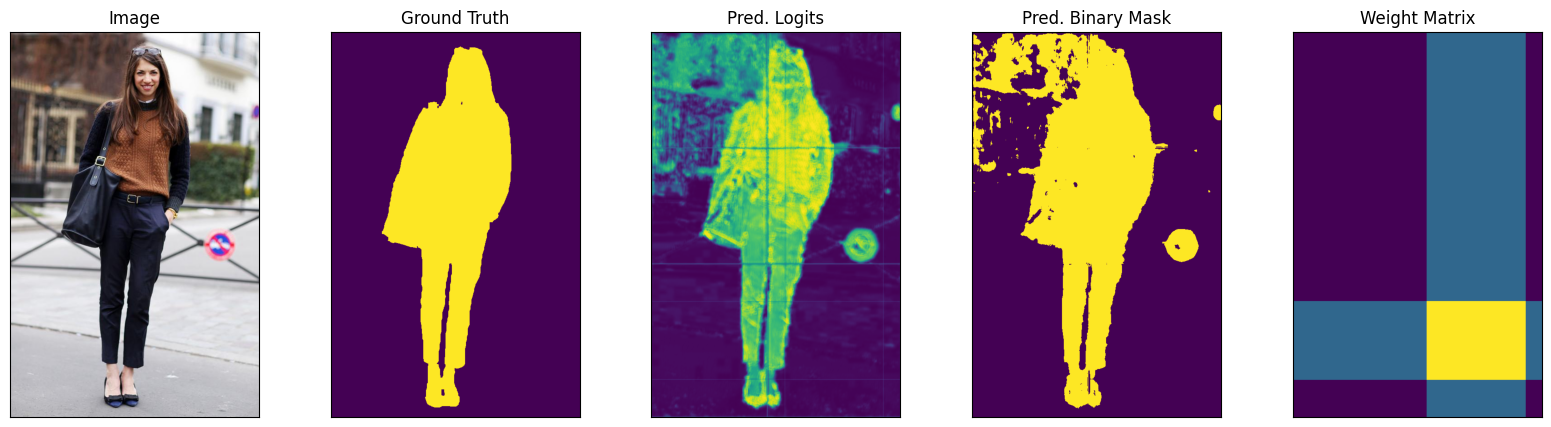

In [651]:
f, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat[1])
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Pred. Logits')

ax[3].imshow(y_hat_bin)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Pred. Binary Mask')

ax[4].imshow(y_wei[0])
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Weight Matrix')

plt.show()

As we can see, the results are not ideal. The truth is that, to make this feasible to run in a short time we used a very small network (only 19K parameters vs. 21M in ResNet18) and performed few training iterations. This is a result that can definitely be improved (and you can try!), but there is a more efficient and effective alternative that solves these issues. We will see it next.

| Experiment      | Inference time    | Sample | Accuracy | IoU  | Dice |
|:---------------:|:----------------:|:------:|:--------:|:----:|:----:|
| Sliding Window  | 30m* / image     | 0851   | 83.89    | 0.56 | 0.71 |
| FCNN            | 1s / image       | 0851   | 79.76    | 0.34 | 0.51 |

*Inference time for the sliding window approach may be reduced applying batches.

## <span style="color:#D52B29">Encoder-Decoder Architecture</span>

In previous sections, we saw that convolutional networks used for classification extract information from the original image at multiple levels. Each level compresses information more, producing richer features. However, in the first strategy (sliding window), this does not help for segmentation since we would need to classify pixel by pixel.

The second strategy we explored does not compress the information and works at the original resolution, allowing segmentation in a single pass. Unfortunately, it is also not ideal due to the high computational cost.

The solution is to <span style="color:#D52B29">combine both approaches</span>. We will use <span style="color:#D52B29">FCNNs that internally compress and decompress information</span>. Pooling layers reduce dimensionality (<span style="color:#D52B29">encoder</span>), while deconvolution or upsampling layers restore it (<span style="color:#D52B29">decoder</span>). Additionally, most architectures include <span style="color:#D52B29">skip-connections</span> that transfer information from the encoder to the decoder for more precise reconstruction.

Among encoder-decoder architectures, there are many variations. Fastai focuses on the most widely used one due to its strong generalization across tasks: the <span style="color:#D52B29">U-Net</span>, named after the "U" shape of its structure, as illustrated below.

![Arquitectura Unet](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Imagen from: [U-Net: Convolutional Networks for Biomedical Image Segmentation
](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/#:~:text=The%20u%2Dnet%20is%20convolutional,and%20precise%20segmentation%20of%20images.&text=U%2Dnet%20architecture%20(example%20for,on%20top%20of%20the%20box.).

As we can see, the architecture starts with a CNN-like <span style="color:#D52B29">encoder</span>, consisting of convolutional and pooling layers. This part can be replaced with any CNN we’ve seen before (e.g., <span style="color:#D52B29">ResNet</span>), also called the <span style="color:#D52B29">backbone</span>. After compression, the <span style="color:#D52B29">decoder</span> uses upsampling and convolutional layers to restore spatial resolution. The horizontal arrows are <span style="color:#D52B29">skip-connections</span>, which pass features from each encoder level to the corresponding decoder layer, improving spatial accuracy.

Although there are technical complexities like undoing pooling (<span style="color:#D52B29">upsampling</span>) or implementing deconvolutions, these details are abstracted when using Fastai’s <span style="color:#D52B29">U-Net</span> implementation, so we will focus on its practical use rather than the low-level operations.

To implement the <span style="color:#D52B29">U-Net</span> and other more advanced semantic segmentation architectures, we will use the <span style="color:#D52B29">Segmentation Models PyTorch</span> library. This library allows us to easily choose different encoders and configure various internal parameters of the network.

Next, we will see how to instantiate a <span style="color:#D52B29">U-Net</span> that uses a <span style="color:#D52B29">ResNet18 encoder</span> pre-trained on ImageNet.

In [653]:
import segmentation_models_pytorch as smp

In [657]:
model = smp.Unet(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=3,
    classes=2
)

model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [658]:
x = torch.rand(1, 3, 256, 256)
y_hat = model(x)
y_hat.shape

torch.Size([1, 2, 256, 256])

We are now going to modify the <span style="color:#D52B29">LightningModule</span> to make use of this new <span style="color:#D52B29">U-Net model</span> and train it with the same parametrization as in the previous experiments, ensuring a <span style="color:#D52B29">fair comparison</span>.

In [659]:
class LightningModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        
        # Creating model
        self.model = smp.Unet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=2
        )

        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        
    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1)) # y: (BS, 1, H, W) -> (BS, H, W)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.training_step_outputs['loss'] += loss.detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1))
        
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.validation_step_outputs['loss'] += loss.detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return loss

    def on_train_epoch_end(self): 
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        print(f"Average training loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.training_step_outputs.clear() 

    def on_validation_epoch_end(self):
        avg_loss = self.validation_step_outputs['loss'] / self.validation_step_outputs['steps']
        print(f"Average validation loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.validation_step_outputs.clear() 

In [660]:
from lightning.pytorch.loggers import CSVLogger

# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

# Intantiate LightningModule
lightning_module = LightningModule()

# Define a CSV logger to store training/validation metrics in CSV format.
csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_unet")

# Define a checkpoint callback:
# It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)

# Create a PyTorch Lightning trainer
trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])

# Load the data module
data_module = DataModule(df, bs=64, ps=224)

# Train the model with the trainer, passing the core LightningModule and data module.
trainer.fit(lightning_module, data_module)

Seed set to 42
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/tmp/ipykernel_84521/1450964625.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['coords'] = valid_df.image_path.apply(lambda x : self.patch_origins(*imread(x).shape[:-1], ps=224, overlap=1).tolist())
/tmp/ipykernel_84521/1450964625.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Sanity Checking: |                                                                                            …

Average validation loss for epoch 0: 1.7487


/home/conda/envs/py311/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                                                   …

...

Epoch 28, global step 319: 'val_loss' was not in top 1


Average validation loss for epoch 28: 0.0794
Average training loss for epoch 28: 0.0796


Validation: |                                                                                                 …

Epoch 29, global step 330: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Average validation loss for epoch 29: 0.0873
Average training loss for epoch 29: 0.0673


   epoch  step  train_loss   val_loss
0      0    10    0.417222  39.114971
1      1    21    0.215378   1.939123
2      2    32    0.186887   0.372676
3      3    43    0.153339   0.134510
4      4    54    0.136732   0.136498


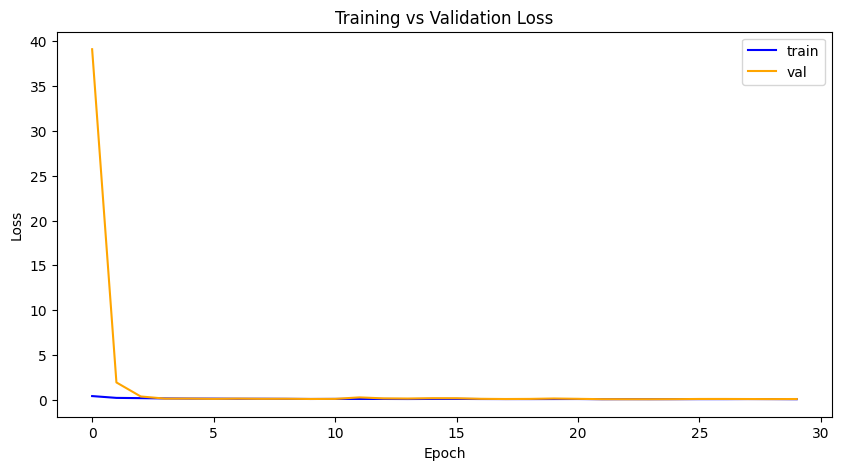

In [661]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.show()

We will now load the best model and perform inference as before, in order to compute metrics and compare this approach with the previous ones.

In [662]:
# Load the best model
model = LightningModule.load_from_checkpoint(model_checkpoint_callback.best_model_path, model=model)
model.cuda(0) # Move to GPU
model.eval()

LightningModule(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1):

In [663]:
ps = 256 # Imagenet Resizes to 256

inf_transforms = T.Compose([
    # T.Resize(size=(256, 256)),    
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

metric_dict = []

test_df = df.query('set == "test"')

mb = master_bar(test_df.iterrows(), total=test_df.shape[0])

for i, r in mb:

    # Read image and mask
    x = imread(r.image_path)
    y = imread(r.mask_path)
    
    # Convert into binary mask and take central pixel value
    y = (y != np.array([69,  6, 90])).any(-1)
    
    # Compute origins
    h, w = y.shape
    coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()

    # Initialize y_hat
    y_hat = torch.zeros((2, h, w), dtype=torch.float32)
    y_wei = torch.zeros((1, h, w), dtype=torch.uint8) # Times each pixel has been infered
    
    # Perform inference
    for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            
        # Crop
        xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
        
        # Convert to PIL image.
        xi = to_pil_image(xi.astype('float32'))
        
        # Apply transforms
        xi = inf_transforms(xi)

        # Forward
        with torch.no_grad():
            logits = model(xi.cuda(0).unsqueeze(0))
            logits = nn.Softmax(1)(logits).detach().cpu()[0]

        # Store predictions
        y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += logits
        y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

    # Normalize logits and gen binary mask
    y_hat /= y_wei
    y_hat_bin = y_hat.argmax(0)

    # Compute metrics
    metric_dict.append({
        'pixel_acc': accuracy_score(y_hat_bin.ravel(), y.ravel()),
        'iou': jaccard_score(y_hat_bin.ravel(), y.ravel()),
        'dice': f1_score(y_hat_bin.ravel(), y.ravel())
    })

Epoch 154/154 :                                                                       

In [664]:
pd.DataFrame.from_records(metric_dict).mean(0)

pixel_acc    0.967562
iou          0.890815
dice         0.937486
dtype: float64

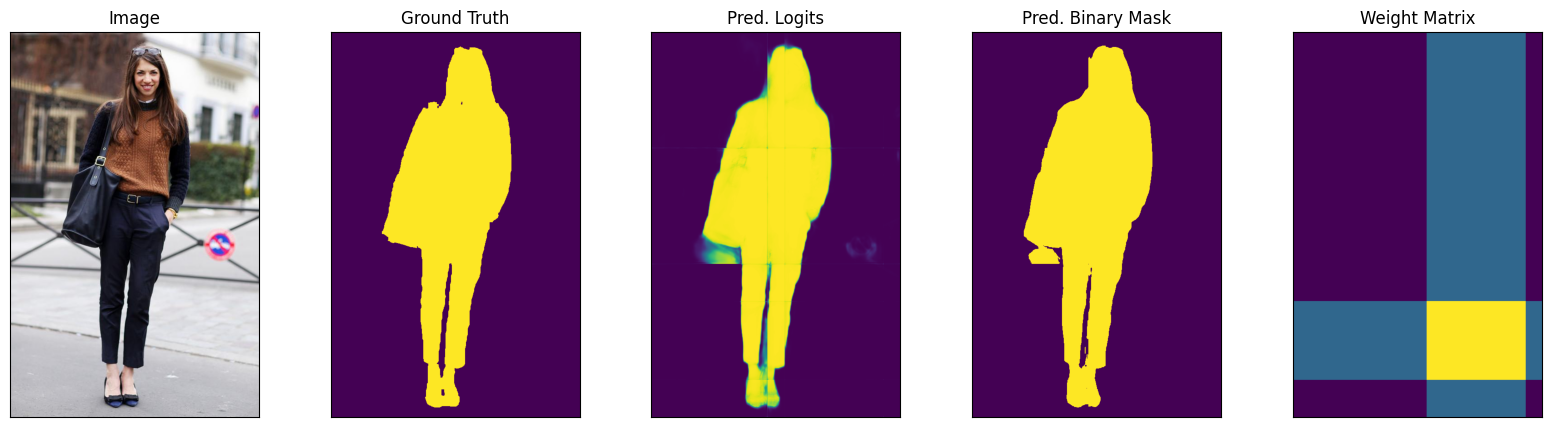

In [665]:
f, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat[1])
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Pred. Logits')

ax[3].imshow(y_hat_bin)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Pred. Binary Mask')

ax[4].imshow(y_wei[0])
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Weight Matrix')

plt.show()

As we can see, the results obtained with <span style="color:#D52B29">U-Net</span> are the best so far. We not only gain in <span style="color:#D52B29">efficiency</span> but also in <span style="color:#D52B29">accuracy</span>. This strategy is therefore the one we should follow to tackle <span style="color:#D52B29">semantic segmentation</span> problems.

| Experiment      | Inference time    | Sample | Accuracy | IoU  | Dice |
|:---------------:|:----------------:|:------:|:--------:|:----:|:----:|
| Sliding Window  | 30m* / image     | 0851   | 83.89    | 0.56 | 0.71 |
| FCNN            | 1s / image       | 0851   | 79.76    | 0.34 | 0.51 |
| U-Net           | 1s / image       | 0851   | 94.98    | 0.81 | 0.89 |

*Inference time for the sliding window approach may be reduced applying batches.

There are, of course, other <span style="color:#D52B29">semantic segmentation</span> architectures besides U-Net (although most share the same <span style="color:#D52B29">encoder-decoder</span> principle). The <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to try out different configurations. I encourage you to experiment with them!

## <span style="color:#D52B29">Summary</span>

In this exercise, you have learned the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a key task in <span style="color:#D52B29">computer vision</span> where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike <span style="color:#D52B29">classification</span>, which predicts a single label for an entire image, or <span style="color:#D52B29">detection</span>, which localizes objects with bounding boxes, segmentation provides a much more detailed and structured understanding of visual content.

We have worked with the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, simplified into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

Throughout the notebook, you explored three different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

You have seen how early methods, like the sliding window, can be conceptually simple but computationally inefficient. The FCN approach introduced a step forward, producing full-resolution masks in a single pass, but still suffered from accuracy issues. Finally, the U-Net architecture combined the strengths of both approaches by compressing and then reconstructing the information with the help of <span style="color:#D52B29">skip-connections</span>, leading to the best results both in terms of <span style="color:#D52B29">efficiency</span> and <span style="color:#D52B29">accuracy</span>.

As a takeaway, you should now understand not only how different architectures perform in practice, but also why <span style="color:#D52B29">encoder-decoder models</span> such as <span style="color:#D52B29">U-Net</span> have become the standard in semantic segmentation. Finally, remember that there are many other segmentation architectures beyond U-Net (most sharing the encoder-decoder principle), and the <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to experiment with them.